interactive(children=(FloatSlider(value=1.0, description='k1 (State 1 slope)', max=3.0, min=-3.0), FloatSlider…

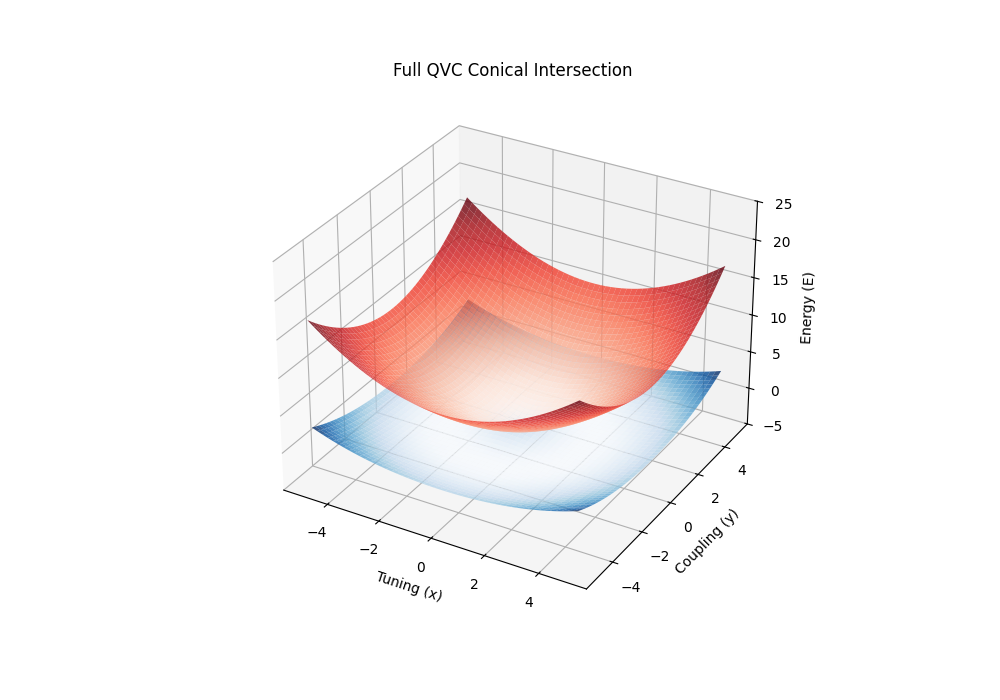

In [4]:
# Run this in a Jupyter Notebook cell
# Ensure you have the required libraries: pip install ipympl ipywidgets numpy matplotlib

%matplotlib widget 
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Create the grid
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)

# 2. Set up the figure and 3D axis
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
fig.canvas.toolbar_visible = False # Cleans up the UI

# 3. The main drawing function
def update_plot(k1=1.0, k2=-1.0, lam=1.0, 
                g1xx=0.2, g1yy=0.2, g2xx=0.2, g2yy=0.2, 
                g1xy=0.0, g2xy=0.0):
    
    ax.clear() # Clear previous surfaces
    
    # --- The QVC Diabatic Matrix ---
    # State 1: Linear tuning + Harmonic bowl + Bilinear twist
    H11 = k1*X + g1xx*(X**2) + g1yy*(Y**2) + g1xy*(X*Y)
    
    # State 2: Linear tuning + Harmonic bowl + Bilinear twist
    H22 = k2*X + g2xx*(X**2) + g2yy*(Y**2) + g2xy*(X*Y)
    
    # Off-diagonal: Linear coupling
    H12 = lam*Y
    
    # --- Diagonalization to Adiabatic Surfaces ---
    mean_E = (H11 + H22) / 2.0
    diff_E = (H11 - H22) / 2.0
    gap = np.sqrt(diff_E**2 + H12**2)
    
    Z_upper = mean_E + gap
    Z_lower = mean_E - gap
    
    # --- Plotting ---
    ax.plot_surface(X, Y, Z_upper, cmap='Reds', alpha=0.8, edgecolor='none')
    ax.plot_surface(X, Y, Z_lower, cmap='Blues', alpha=0.8, edgecolor='none')
    
    # Formatting
    ax.set_xlabel('Tuning (x)')
    ax.set_ylabel('Coupling (y)')
    ax.set_zlabel('Energy (E)')
    ax.set_zlim(-5, 25) # Expanded Z-axis to accommodate quadratic growth
    ax.set_title("Full QVC Conical Intersection")
    
    # Force drawing update
    fig.canvas.draw_idle()

# 4. Create interactive sliders
# Grouped to keep the UI somewhat organized
controls = widgets.interactive(
    update_plot, 
    # Linear Terms
    k1=widgets.FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.1, description='k1 (State 1 slope)'),
    k2=widgets.FloatSlider(value=-1.0, min=-3.0, max=3.0, step=0.1, description='k2 (State 2 slope)'),
    lam=widgets.FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description='λ (Coupling)'),
    
    # Quadratic Harmonic Terms
    g1xx=widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description=r'$\\gamma_{1xx}$'),
    g1yy=widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='γ_1yy'),
    g2xx=widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='γ_2xx'),
    g2yy=widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description='γ_2yy'),
    
    # Quadratic Bilinear (Twist) Terms
    g1xy=widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05, description='γ_1xy (Twist 1)'),
    g2xy=widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05, description='γ_2xy (Twist 2)')
)

# Display the UI
display(controls)